In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['OMP_NUM_THREADS'] = "64"

# file ops
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings(action="ignore", category=RuntimeWarning)

# spatial
import xarray as xa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rioxarray
import cartopy.crs as ccrs

# machine learning
from dask.distributed import get_client, Client, LocalCluster, SSHCluster
from concurrent.futures import ThreadPoolExecutor
import xgboost as xgb

# custom
from coralshift.utils import file_ops, config, utils
from coralshift.utils.config import Config
from coralshift.dataloading import get_data
# from coralshift.plotting import spatial_plots, visualise_results
from coralshift.machine_learning import static_models, run_model, ml_results
from coralshift.processing import ml_processing
from coralshift.processing import spatial_data

from tqdm.auto import tqdm
import cmipper
from graphpy import spatial as graphy_spatial
import cmipper.utils as cmipper_utils

# data fps
gt_data_dir = config.gt_data_dir
config_info = file_ops.read_yaml(config.config_dir / "config_test.yaml")
config_class = Config(config_info)

/maps/rt582/miniforge3/envs/shiftpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Get data

### Global reefs

Loading UNEP_GDCR xarray at 0.250 degrees resolution.
loading from /maps-priv/maps/rt582/coralshift/data/ground_truth/UNEP_GDCR/rasters/unep_0-25_S90-0_N90-0_W180-0_E180-0.nc


(<Figure size 3000x3000 with 2 Axes>,
 <GeoAxes: title={'center': 'UNEP 0.25 degree resolution'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x77bc3bfb31d0>)

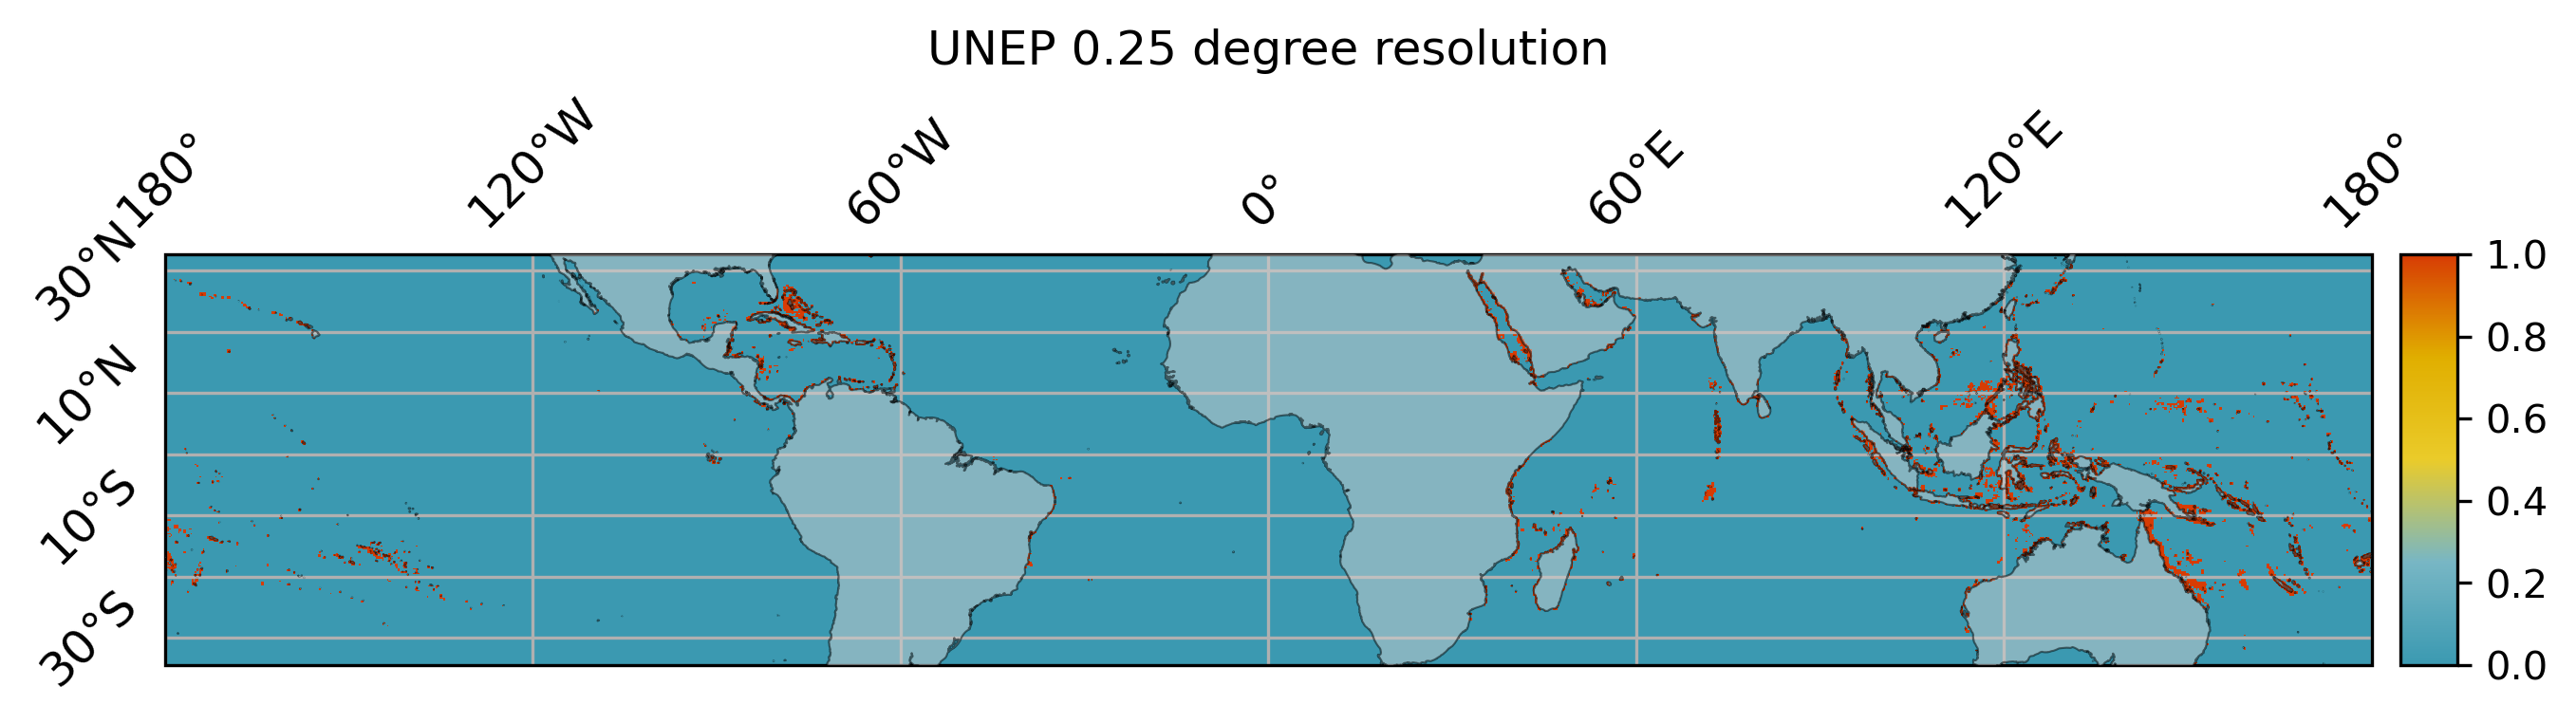

In [2]:
# generate global coral presence at 0.25 degree resolution
config_class.resolution = 0.25

unep_0_25_raster = get_data.generate_xa_ds_from_shapefile(
    shapefile_id = "UNEP_GDCR",
    shapefile_fp = config.gdcr_dir / "01_Data/WCMC008_CoralReef2021_Py_v4_1.shp",
    degrees_resolution = 0.25
    
)
graphy_spatial.plot_spatial(unep_0_25_raster["UNEP_GDCR"], title="UNEP 0.25 degree resolution")

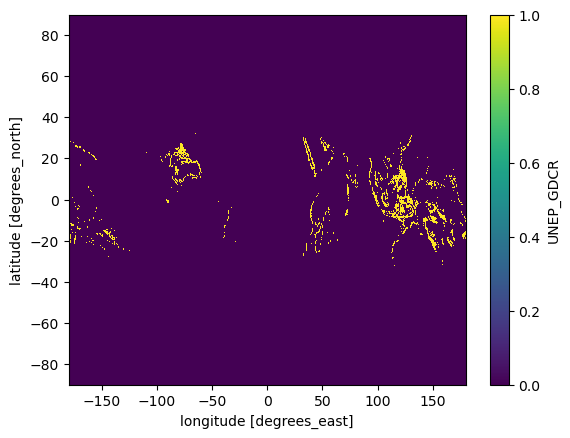

In [8]:
# map to regular grid over whole globe
target_latitudes = np.arange(-90, 90, 0.25)  # Regular global latitudes at 0.25°
target_longitudes = np.arange(-180, 180, 0.25)  # Regular global longitudes at 0.25°

# Perform interpolation to the regular latitude grid (fill with NaNs where no data exists)
unep_0_25_raster_regular = unep_0_25_raster.interp(
    latitude=target_latitudes,
    longitude=target_longitudes,
    method="linear"  # Use nearest-neighbor interpolation for simplicity
)

# Replace NaNs with zeros for areas outside the original lat/lon range
unep_0_25_raster_regular = unep_0_25_raster_regular.fillna(0)
# cast any non-zero values to 1
unep_0_25_raster_regular = unep_0_25_raster_regular.where(unep_0_25_raster_regular == 0, 1)
unep_0_25_raster_regular.UNEP_GDCR.plot()

# save
# unep_0_25_raster_regular.astype(np.int8).to_netcdf("/maps-priv/maps/rt582/coralshift/data/ground_truth/UNEP_GDCR/rasters/unep_0-25_S90-0_N90-0_W180-0_E180-0_regular.nc")

### Global Bathymetry

In [6]:
og_bath = spatial_data.process_xa_d(xa.open_dataset(config.bathymetry_dir / "gebco/GEBCO_2023_n90-0_s90-0_w180-0_e180-0.nc"))
n_lats = 720
n_lons = 1440

# find maximum elevation (minimum value in ocean)
coarse_bath = og_bath.coarsen(
    longitude=int(len(og_bath.longitude.values) / n_lons), 
    latitude=int((len(og_bath.latitude.values) / n_lats))).max()

(<Figure size 3000x3000 with 2 Axes>,
 <GeoAxes: title={'center': 'Bathymetry 0.25 degree resolution'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x77bc2e171310>)

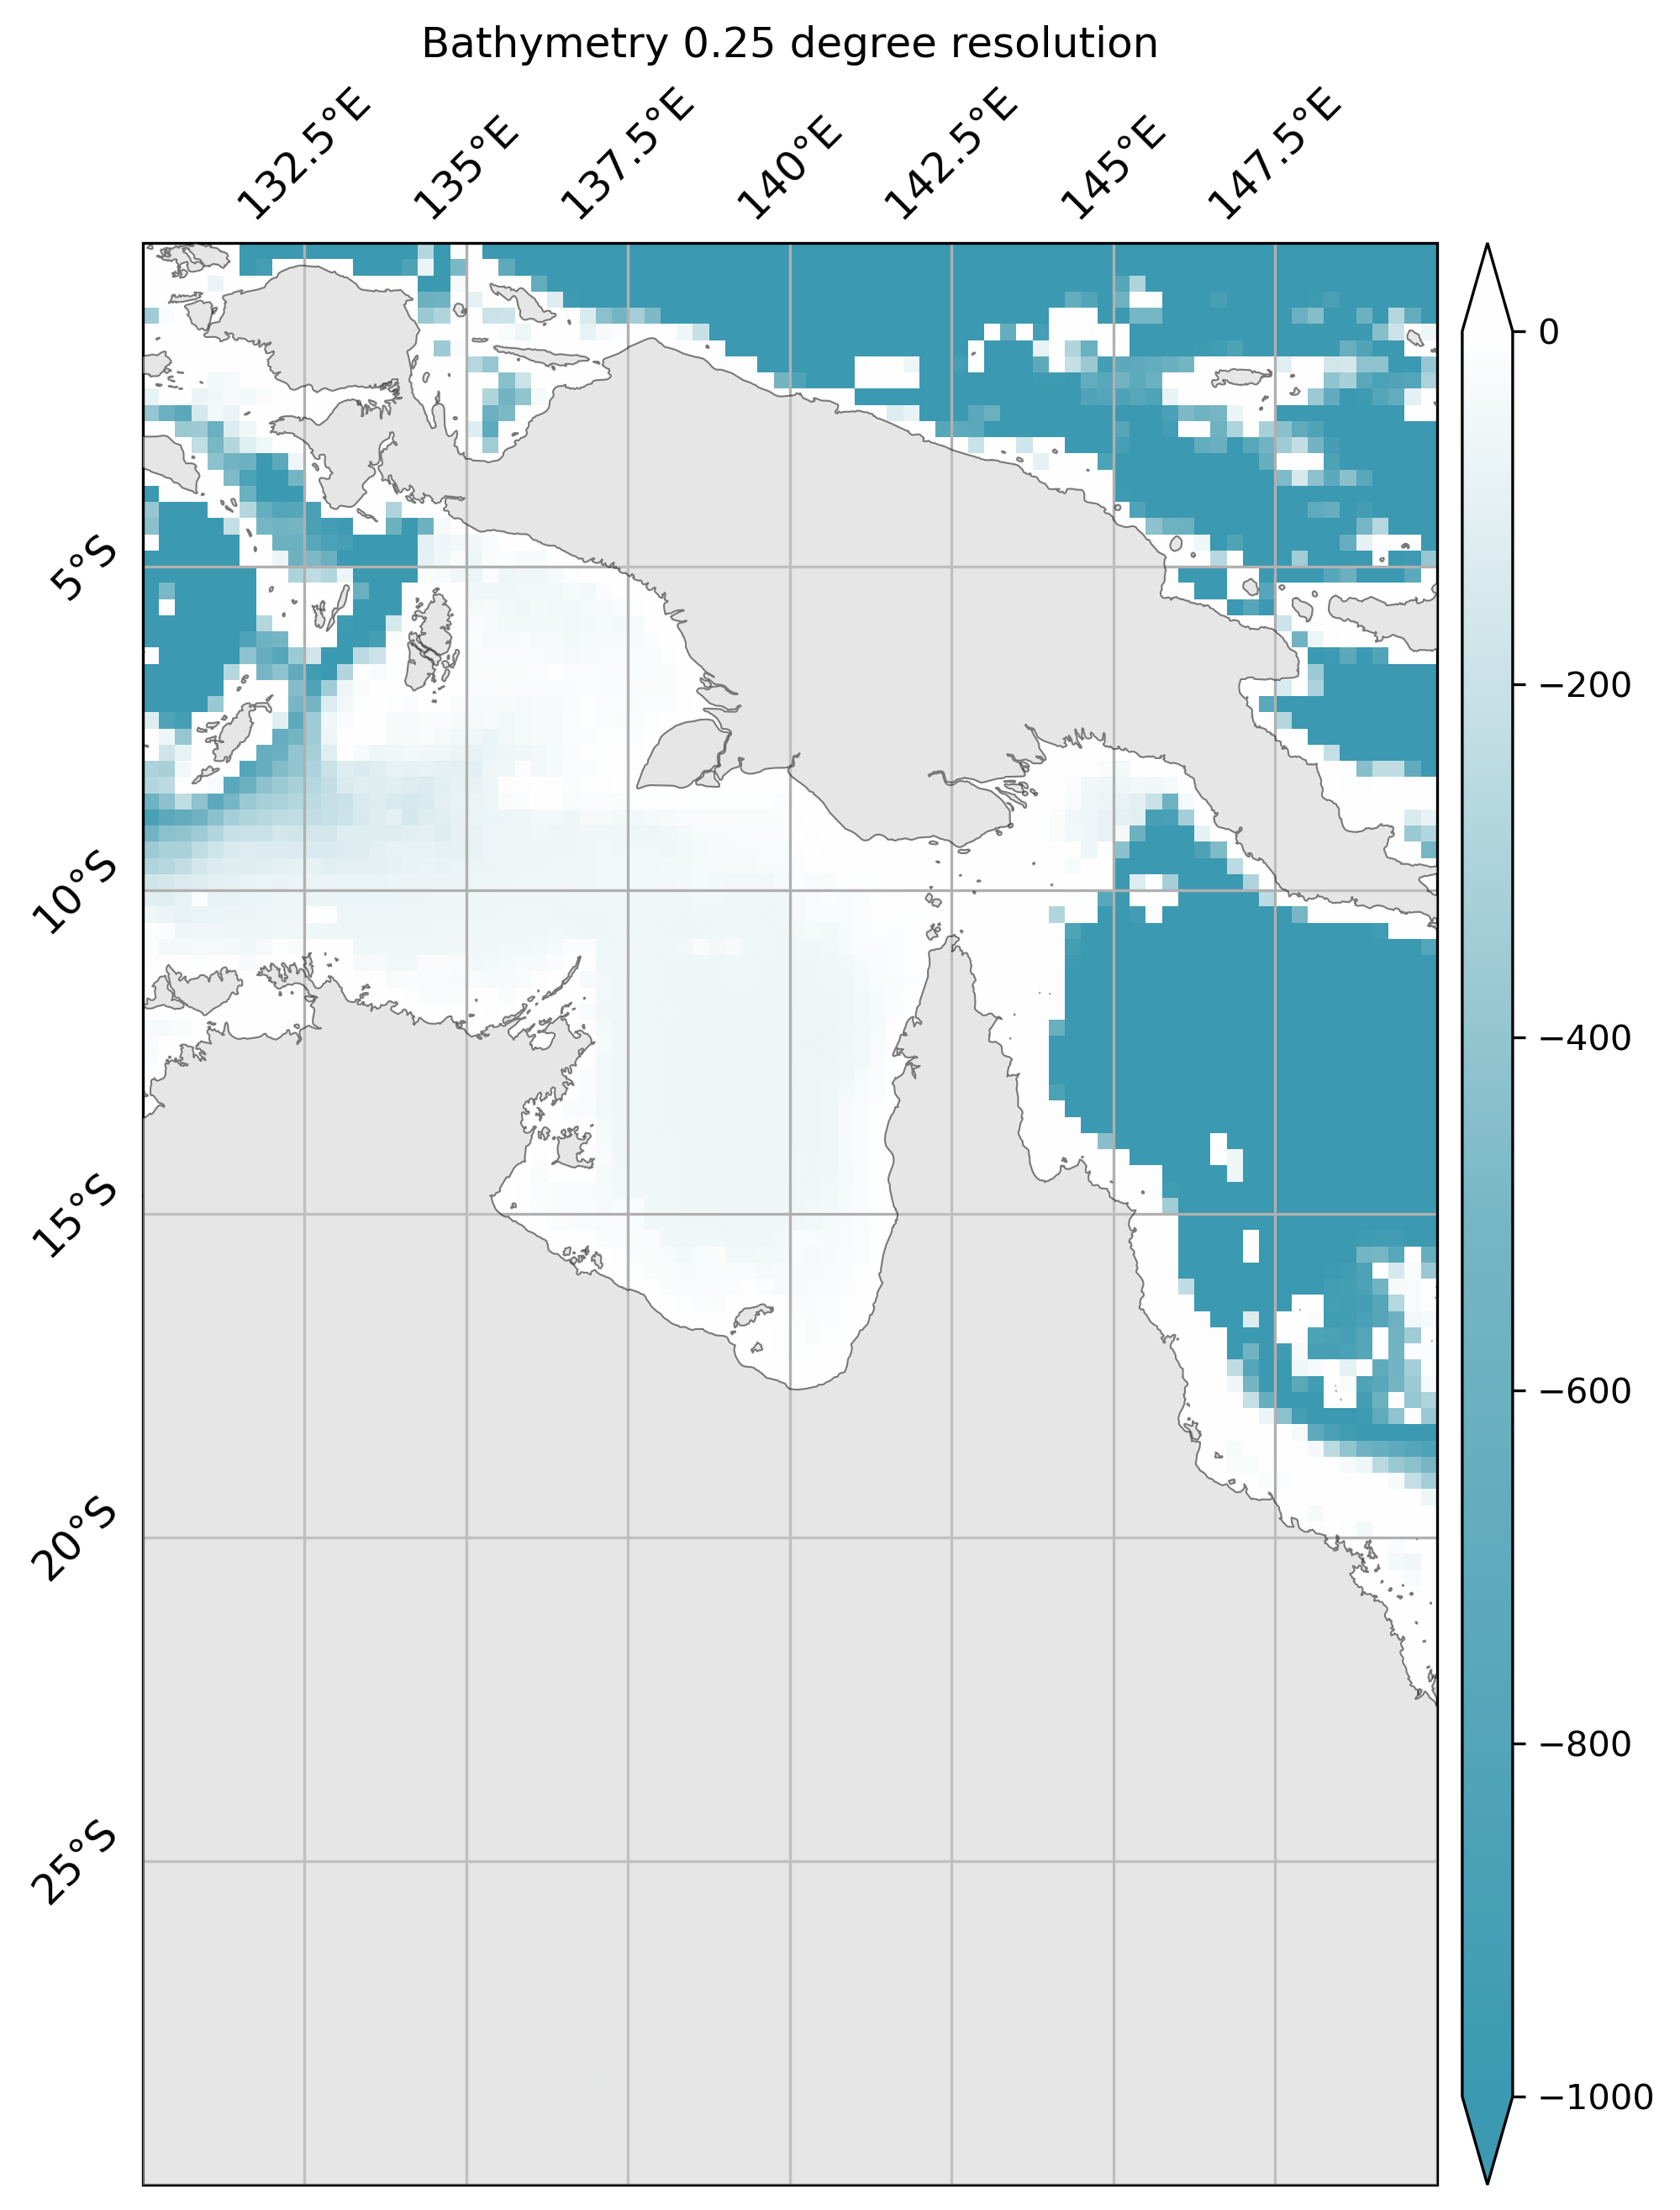

In [ ]:
graphy_spatial.plot_spatial(coarse_bath["elevation"].sel(latitude=slice(-30,0), longitude=slice(130,150)),
                            title="Bathymetry 0.25 degree resolution", 
                            val_lims = [-1000,0]
                            , cbar_dict={"cmap_type": "lim_blue"}
                            )

# save coarse bathymetry
# coarse_bath.to_netcdf("/maps/rt582/coralshift/data/bathymetry/gebco/rasters/GEBCO_2023_n90-0_s90-0_w180-0_e180-0_0_25_max.nc")

TODO: pythonise.

Following generation of coarse bathymetry, run the following in the terminal:

```cdo -P 16 remapcon,/maps/rt582/coralshift/data/bathymetry/gebco/bath_0_25_remap.txt /maps/rt582/coralshift/data/bathymetry/gebco/rasters/GEBCO_2023_n90-0_s90-0_w180-0_e180-0_0_25_max.nc /maps/rt582/coralshift/data/bathymetry/gebco/rasters/GEBCO_2023_n90-0_s90-0_w180-0_e180-0_0_25_max_bilinear.nc```

### Combine bathymetry and reef data

In [ ]:
merged = xa.merge([coarse_bath, unep_gdcr_0_25_regular])
# merged.to_netcdf(Path("/maps/rt582/coralshift/data/rcuk24") / "bathymetry_unep_0-25_S90-0_N90-0_W180-0_E180-0_regular.nc")

## Environmental datasets